# Exploratory Data Analysis & Data Preparation
**Phạm Quang Minh | Student ID: 104999568**

COS40007 Artificial Intelligence Engineering - Portfolio Assessment 1

Date: 4 October 2026 | Swinburne University of Technology

## Generative AI declaration
OpenAI Codex (GPT-6) assisted with debugging, code polishing and the report. The overall structures,
interpretations and final say are my own.

## Purpose and reproducibility
Investigate how concrete mixture ingredients and curing age relate to measured
compressive strength, audit data quality, and prepare a transparent dataset for
later modelling. This portfolio addresses Tasks 1-9 of the supplied brief.
The colleague's submission was consulted for structure only; no colleague code
or analysis is reproduced. No model is trained, as requested by the report template.

Run all cells in order from this notebook's directory. Install the packages in
`requirements.txt` first. The original UCI workbook is included under `data/`;
no network connection is needed to execute the notebook.

# Task 1. Dataset loading and initial exploration
The UCI Concrete Compressive Strength dataset contains laboratory strength
measurements for mixture recipes at specified ages. It has eight quantitative
predictors and one continuous target. Ingredient quantities are in kg/m^3,
age is in days and compressive strength is in MPa. The original problem is
regression; the assignment also requests discretised labels for classification.

Source: Yeh, I. (1998). Concrete Compressive Strength [Dataset]. UCI Machine
Learning Repository. https://doi.org/10.24432/C5PK67 (accessed 6 October 2026).
UCI reports 1,030 observations and no missing values. These claims are checked
against the actual file rather than assumed.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 100)
pd.set_option('display.precision', 3)
sns.set_theme(style='whitegrid', font_scale=0.9)
DATA = Path('data/Concrete_Data.xls')
assert DATA.exists(), 'Run from the portfolio-1 directory.'
columns = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer',
           'coarse_aggregate', 'fine_aggregate', 'age', 'strength']
raw = pd.read_excel(DATA, engine='xlrd')
assert raw.shape == (1030, 9), 'Unexpected source shape.'
original_headers = list(raw.columns)
raw.columns = columns
predictors = columns[:-1]
units = {c: 'kg/m^3' for c in predictors[:-1]}
units.update(age='days', strength='MPa')
labels = {c: f'{c.replace("_", " ").title()} ({units[c]})' for c in columns}
Path('figures').mkdir(exist_ok=True)

def show_plot(name):
    plt.savefig(Path('figures') / f'{name}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close('all')

def show_table(table):
    # Text tables are retained verbatim in both notebook and PDF.
    print(table.to_string())

print('Source: UCI dataset 165, original Concrete_Data.xls')
print('SHA-256:', hashlib.sha256(DATA.read_bytes()).hexdigest())
print('Raw shape:', raw.shape)
show_table(pd.DataFrame({'original_header': original_headers,
                         'analysis_name': columns, 'unit': [units[c] for c in columns]}))

Source: UCI dataset 165, original Concrete_Data.xls
SHA-256: 710076c66b9ca3f8050e7942f3dcbdbe04013534daeb0077ffd3079a52d8e0c4
Raw shape: (1030, 9)
                                         original_header     analysis_name    unit
0              Cement (component 1)(kg in a m^3 mixture)            cement  kg/m^3
1  Blast Furnace Slag (component 2)(kg in a m^3 mixture)              slag  kg/m^3
2             Fly Ash (component 3)(kg in a m^3 mixture)           fly_ash  kg/m^3
3              Water  (component 4)(kg in a m^3 mixture)             water  kg/m^3
4    Superplasticizer (component 5)(kg in a m^3 mixture)  superplasticizer  kg/m^3
5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)  coarse_aggregate  kg/m^3
6      Fine Aggregate (component 7)(kg in a m^3 mixture)    fine_aggregate  kg/m^3
7                                              Age (day)               age    days
8       Concrete compressive strength(MPa, megapascals)           strength     MPa


In [2]:
print('First five observations (original row order):')
show_table(raw.head())
print('Data types:')
show_table(raw.dtypes.to_frame('dtype'))
print('Descriptive statistics:')
show_table(raw.describe().T.round(3))
print('Initial missing counts:')
show_table(raw.isna().sum().to_frame('missing'))

First five observations (original row order):
   cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  fine_aggregate  age  strength
0   540.0    0.0      0.0  162.0               2.5            1040.0           676.0   28    79.986
1   540.0    0.0      0.0  162.0               2.5            1055.0           676.0   28    61.887
2   332.5  142.5      0.0  228.0               0.0             932.0           594.0  270    40.270
3   332.5  142.5      0.0  228.0               0.0             932.0           594.0  365    41.053
4   198.6  132.4      0.0  192.0               0.0             978.4           825.5  360    44.296
Data types:
                    dtype
cement            float64
slag              float64
fly_ash           float64
water             float64
superplasticizer  float64
coarse_aggregate  float64
fine_aggregate    float64
age                 int64
strength          float64
Descriptive statistics:
                   count     mean      std      min      2

All source columns are numeric. Short names improve code readability while the
mapping above preserves the original headers and units. Numerical storage dtype
does not determine measurement meaning: age represents whole days even if a file
stores it as a floating-point value. Initial exploration uses all 1,030 raw rows;
later analysis uses the explicitly deduplicated dataset.

# Task 2. Data quality assessment
Missingness is checked by column and visualised across every raw row. Zero is a
valid value for optional ingredients, not a missing-value code. Duplicates are
defined across all nine fields, including strength; repeated strength values alone
do not identify duplicate observations. Plausibility checks distinguish impossible
values from statistically unusual ones.

                  missing_count  missing_percent
cement                        0              0.0
slag                          0              0.0
fly_ash                       0              0.0
water                         0              0.0
superplasticizer              0              0.0
coarse_aggregate              0              0.0
fine_aggregate                0              0.0
age                           0              0.0
strength                      0              0.0


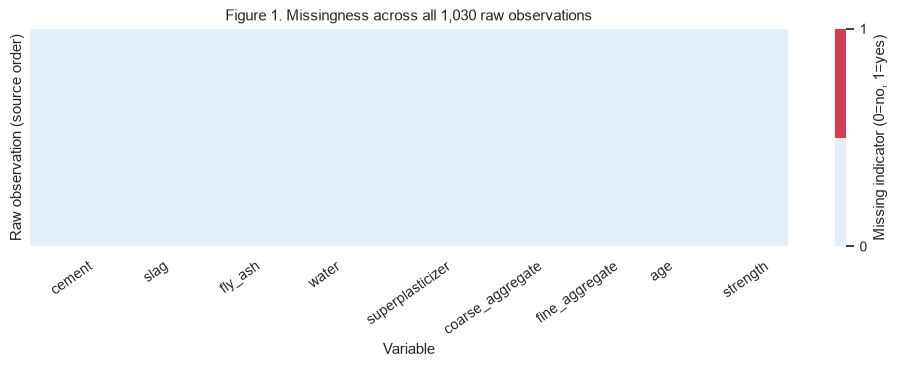

In [3]:
missing = pd.DataFrame({'missing_count': raw.isna().sum(),
                        'missing_percent': 100 * raw.isna().mean()})
show_table(missing)
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(raw.isna().astype(int), ax=ax, cmap=['#e5eff8', '#d43d51'],
            vmin=0, vmax=1, yticklabels=False,
            cbar_kws={'ticks': [0, 1], 'label': 'Missing indicator (0=no, 1=yes)'})
ax.set(title='Figure 1. Missingness across all 1,030 raw observations',
       xlabel='Variable', ylabel='Raw observation (source order)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
show_plot('01_missingness')

In [4]:
extra_duplicates = int(raw.duplicated().sum())
duplicate_members = int(raw.duplicated(keep=False).sum())
print('Extra duplicate rows beyond first occurrence:', extra_duplicates)
print('Rows belonging to duplicate groups:', duplicate_members)
print('Examples (source row index retained):')
show_table(raw.loc[raw.duplicated(keep=False)].sort_values(columns).head(8))
checks = pd.Series({
    'nonfinite_numeric_values': int((~np.isfinite(raw.to_numpy())).sum()),
    'negative_ingredient_values': int((raw[predictors[:-1]] < 0).sum().sum()),
    'nonpositive_cement_values': int((raw.cement <= 0).sum()),
    'nonpositive_water_values': int((raw.water <= 0).sum()),
    'ages_outside_documented_1_to_365_days': int((~raw.age.between(1, 365)).sum()),
    'noninteger_ages': int((raw.age % 1 != 0).sum()),
    'nonpositive_strength_values': int((raw.strength <= 0).sum())})
show_table(checks.to_frame('count'))
clean = raw.drop_duplicates().copy()
clean['age'] = clean['age'].astype('int64')
print('Clean shape:', clean.shape)
print('Rows removed:', len(raw) - len(clean))
print('Types after cleaning:')
show_table(clean.dtypes.to_frame('dtype'))

Extra duplicate rows beyond first occurrence: 25
Rows belonging to duplicate groups: 36
Examples (source row index retained):
     cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  fine_aggregate  age  strength
801   252.0    0.0      0.0  185.0               0.0            1111.0           784.0   28    19.691
809   252.0    0.0      0.0  185.0               0.0            1111.0           784.0   28    19.691
83    362.6  189.0      0.0  164.9              11.6             944.7           755.8    3    35.301
86    362.6  189.0      0.0  164.9              11.6             944.7           755.8    3    35.301
88    362.6  189.0      0.0  164.9              11.6             944.7           755.8    3    35.301
91    362.6  189.0      0.0  164.9              11.6             944.7           755.8    3    35.301
106   362.6  189.0      0.0  164.9              11.6             944.7           755.8    7    55.896
109   362.6  189.0      0.0  164.9              11.6      

Exact repetitions may be repeated tests or accidental duplication; the workbook
has no specimen IDs with which to decide. This portfolio keeps one occurrence per
identical full record to avoid giving identical observations extra weight. This is
an explicit analytical choice, not proof that the source contained recording errors.
Distinct tests with identical recipes and different strengths remain. The raw workbook
is preserved so the decision can be reversed and assessed in future sensitivity work.
No imputation is needed, and zero-valued optional ingredients are retained.

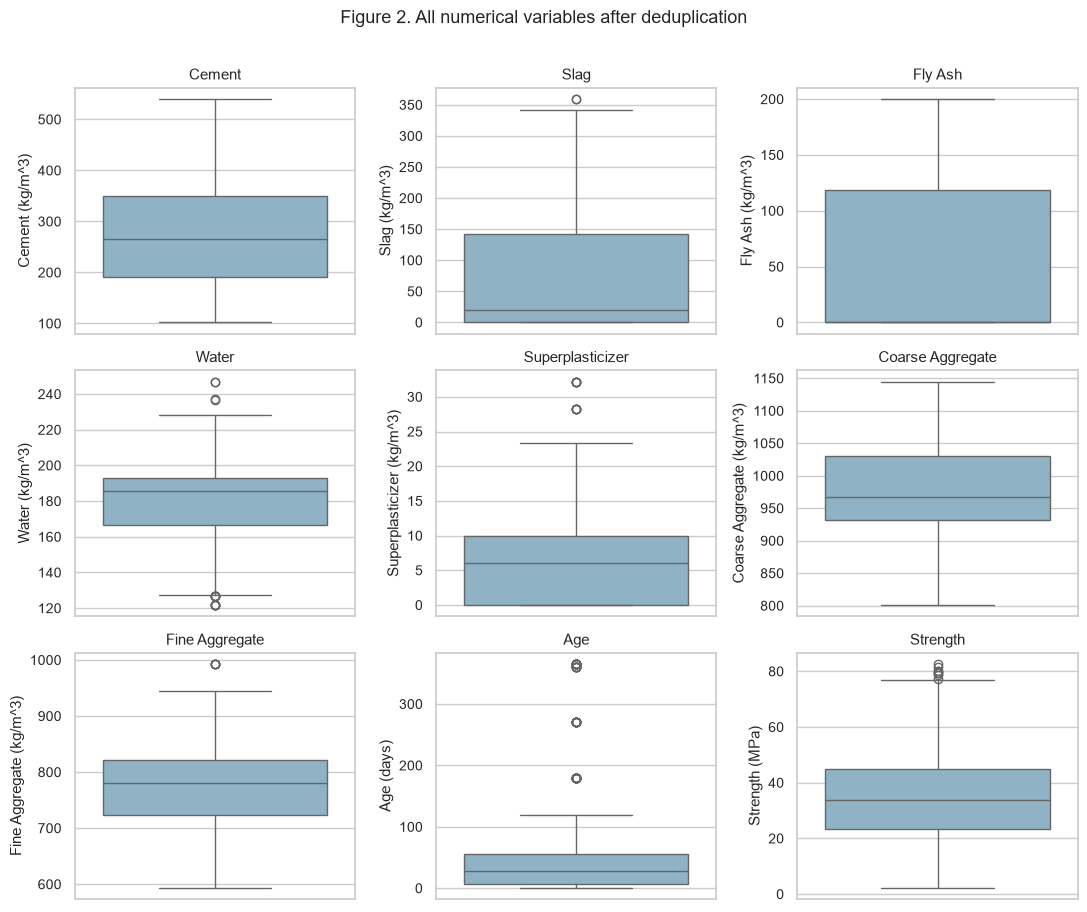

                  lower_fence  upper_fence  flagged_count  flagged_percent
cement                -46.800      586.480              0            0.000
slag                 -213.750      356.250              2            0.199
fly_ash              -177.405      295.675              0            0.000
water                 127.115      232.435             15            1.493
superplasticizer      -15.000       25.000             10            0.995
coarse_aggregate      783.500     1179.500              0            0.000
fine_aggregate        577.450      969.050              5            0.498
age                   -66.500      129.500             59            5.871
strength               -8.494       76.886              8            0.796
Distinct rows flagged in at least one variable: 94


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for c, ax in zip(columns, axes.flat):
    sns.boxplot(y=clean[c], ax=ax, color='#86b4ce')
    ax.set(title=c.replace('_', ' ').title(), ylabel=labels[c], xlabel='')
fig.suptitle('Figure 2. All numerical variables after deduplication', y=1.01)
plt.tight_layout()
show_plot('02_boxplots')
q1, q3 = clean[columns].quantile(0.25), clean[columns].quantile(0.75)
iqr = q3 - q1
flags = (clean[columns] < q1 - 1.5 * iqr) | (clean[columns] > q3 + 1.5 * iqr)
outlier_audit = pd.DataFrame({'lower_fence': q1 - 1.5 * iqr,
                             'upper_fence': q3 + 1.5 * iqr,
                             'flagged_count': flags.sum(),
                             'flagged_percent': 100 * flags.mean()})
show_table(outlier_audit.round(3))
print('Distinct rows flagged in at least one variable:', int(flags.any(axis=1).sum()))

The 1.5-IQR rule is a screening heuristic, not an error detector. Long curing
ages and unusual admixture dosages may be legitimate experimental settings.
All flagged rows are retained because no supplied provenance establishes them as
invalid. Removing them automatically would narrow the engineering range and could
bias a future model toward common mixtures. Separate boxplots use each variable's
own scale, so differences in units do not hide smaller-valued variables.

# Task 3. Target variable preparation
`strength` is the continuous target in MPa. Its original use is regression.
For the required class conversion, four ordered, relative labels are created by
equal-frequency binning on the cleaned data: Lower, Lower-middle, Upper-middle
and Higher strength. Quartiles are selected to balance class counts without
claiming regulatory or structural design thresholds. They describe this sample,
not whether a concrete mixture is safe for a particular application.

Target name: strength; unit: MPa; dtype: float64
Original task: regression; discretised task: ordered classification
       strength_MPa
count      1005.000
mean         35.250
std          16.285
min           2.332
25%          23.524
50%          33.798
75%          44.868
max          82.599
Target skewness: 0.396
              lower_MPa  upper_MPa  count  percent
Lower             2.332     23.523    252   25.075
Lower-middle     23.523     33.798    252   25.075
Upper-middle     33.798     44.868    250   24.876
Higher           44.868     82.599    251   24.975
Exact edges (MPa): [2.331807832, 23.523542168, 33.79811352, 44.868340176000004, 82.5992248]
Intervals: first includes minimum; all subsequent intervals are (lower, upper].
Max/min class-count ratio: 1.008


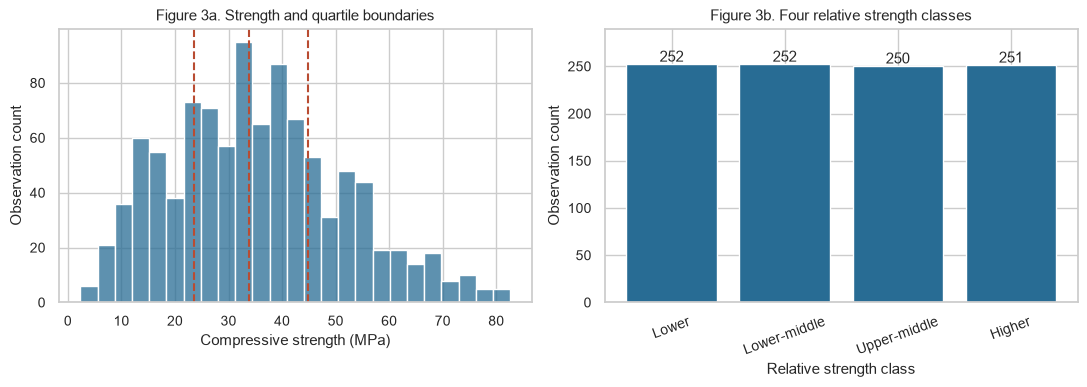

In [6]:
print('Target name: strength; unit: MPa; dtype:', clean.strength.dtype)
print('Original task: regression; discretised task: ordered classification')
show_table(clean.strength.describe().to_frame('strength_MPa'))
print('Target skewness:', round(clean.strength.skew(), 3))
class_labels = ['Lower', 'Lower-middle', 'Upper-middle', 'Higher']
clean['strength_class'], edges = pd.qcut(clean.strength, q=4,
                                         labels=class_labels, retbins=True)
counts = clean.strength_class.value_counts(sort=False)
class_table = pd.DataFrame({'lower_MPa': edges[:-1], 'upper_MPa': edges[1:],
                            'count': counts.to_numpy(),
                            'percent': 100 * counts.to_numpy() / len(clean)},
                           index=class_labels)
show_table(class_table.round(4))
print('Exact edges (MPa):', edges.tolist())
print('Intervals: first includes minimum; all subsequent intervals are (lower, upper].')
print('Max/min class-count ratio:', round(counts.max() / counts.min(), 3))
assert counts.sum() == len(clean) and clean.strength_class.notna().all()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(clean.strength, bins=25, ax=axes[0], color='#286c94')
for edge in edges[1:-1]:
    axes[0].axvline(edge, color='#b94c32', linestyle='--')
axes[0].set(title='Figure 3a. Strength and quartile boundaries',
            xlabel='Compressive strength (MPa)', ylabel='Observation count')
axes[1].bar(class_labels, counts.to_numpy(), color='#286c94')
for i, count in enumerate(counts):
    axes[1].text(i, count + 3, str(count), ha='center')
axes[1].set(title='Figure 3b. Four relative strength classes',
            xlabel='Relative strength class', ylabel='Observation count',
            ylim=(0, counts.max() * 1.15))
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
show_plot('03_target_and_classes')

The histogram shows substantial spread in strength, so a single summary value
would conceal important variation. Quartile labels sacrifice differences within
each interval and make nearly identical strengths on opposite sides of a boundary
different classes. Ties can cause slight count differences; the count ratio above
quantifies balance. Both target representations are retained, but neither target
is permitted as a predictor of the other.

These boundaries are descriptive, computed from the full cleaned dataset for this
EDA. For future evaluation, define engineering thresholds in advance or estimate
quartiles only on training targets and freeze them for held-out data. Use infinite
outer edges for future observations outside the training range. Do not compute
new quartiles on a test set or use held-out target information to tune boundaries.

# Task 4. Univariate analysis
The eight predictors are cement, slag, fly ash, water, superplasticizer, coarse
aggregate, fine aggregate and age. All are quantitative; no categorical predictor
encoding is needed. Histograms include units and counts; skewness and the fraction
of zero values help distinguish asymmetric distributions from absent ingredients.

Predictors: cement, slag, fly_ash, water, superplasticizer, coarse_aggregate, fine_aggregate, age
                   count     mean      std     min     25%    50%      75%     max  skewness  zero_percent
cement            1005.0  278.629  104.345  102.00  190.68  265.0   349.00   540.0     0.565         0.000
slag              1005.0   72.043   86.171    0.00    0.00   20.0   142.50   359.4     0.855        46.269
fly_ash           1005.0   55.535   64.207    0.00    0.00    0.0   118.27   200.1     0.497        53.831
water             1005.0  182.074   21.341  121.75  166.61  185.7   192.94   247.0     0.034         0.000
superplasticizer  1005.0    6.032    5.920    0.00    0.00    6.1    10.00    32.2     0.982        37.612
coarse_aggregate  1005.0  974.376   77.580  801.00  932.00  968.0  1031.00  1145.0    -0.065         0.000
fine_aggregate    1005.0  772.687   80.340  594.00  724.30  780.0   822.20   992.6    -0.252         0.000
age               1005.0   45.857   63.735    

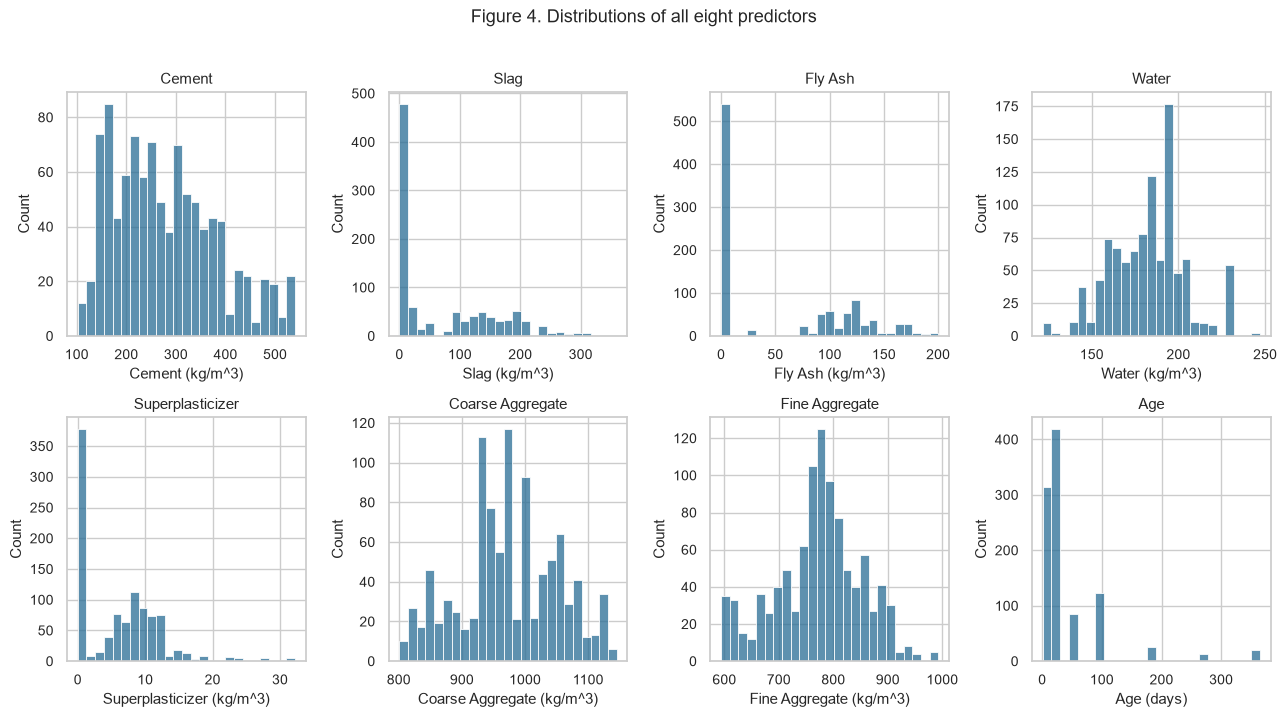

In [7]:
print('Predictors:', ', '.join(predictors))
summary = clean[predictors].describe().T
summary['skewness'] = clean[predictors].skew()
summary['zero_percent'] = 100 * clean[predictors].eq(0).mean()
show_table(summary.round(3))
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for c, ax in zip(predictors, axes.flat):
    sns.histplot(clean[c], bins=25, ax=ax, color='#286c94')
    ax.set(title=c.replace('_', ' ').title(), xlabel=labels[c], ylabel='Count')
fig.suptitle('Figure 4. Distributions of all eight predictors', y=1.02)
plt.tight_layout()
show_plot('04_predictor_histograms')

Cement has a broad, asymmetric distribution rather than a single narrow recipe.
Slag and fly ash have many zeros and distinct positive ranges, reflecting mixtures
with and without supplementary materials. Superplasticizer is also zero-heavy
with a positive tail. Age is discrete and strongly right-skewed: common test ages
create spikes and a smaller number of long-age tests extend the tail. Water and
aggregate quantities are more concentrated but can reflect several recipe families;
visual symmetry alone does not establish normality. Skewness is descriptive and
does not by itself justify deleting observations or transforming every variable.

# Task 5. Multivariate analysis
Pearson correlation measures linear association with continuous strength. Features
are ranked by absolute correlation, while their signs are preserved. Spearman
correlation provides a complementary rank-based view when relations are monotonic
but nonlinear. Correlations are descriptive associations, not causal effects.

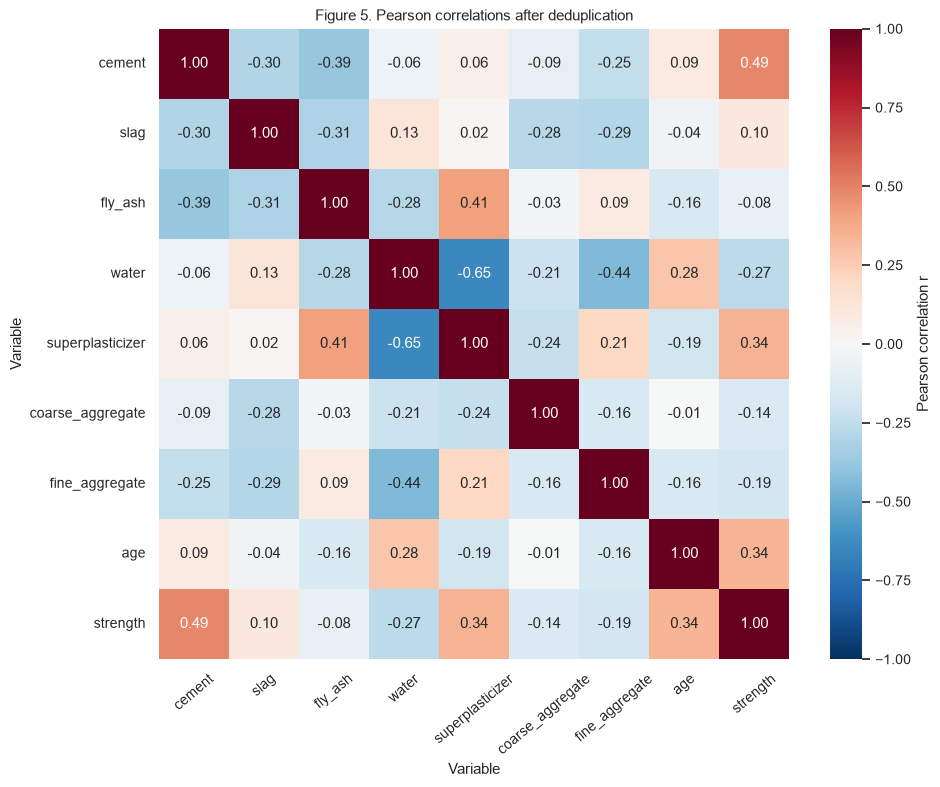

All features ranked by absolute Pearson correlation:
                  Pearson_r  Spearman_rho  absolute_Pearson_r
cement                0.488         0.461               0.488
superplasticizer      0.344         0.322               0.344
age                   0.337         0.605               0.337
water                -0.270        -0.284               0.270
fine_aggregate       -0.186        -0.193               0.186
coarse_aggregate     -0.145        -0.163               0.145
slag                  0.103         0.139               0.103
fly_ash              -0.081        -0.057               0.081
Top three: cement: r=0.4883, superplasticizer: r=0.3442, age: r=0.3374
Strongest predictor pairs:
   feature_1         feature_2      r  absolute_r
18     water  superplasticizer -0.647       0.647
20     water    fine_aggregate -0.445       0.445
14   fly_ash  superplasticizer  0.414       0.414
1     cement           fly_ash -0.386       0.386
7       slag           fly_ash -0.312    

In [8]:
corr = clean[columns].corr(method='pearson')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1, center=0,
            cmap='RdBu_r', square=True, ax=ax,
            cbar_kws={'label': 'Pearson correlation r'})
ax.set(title='Figure 5. Pearson correlations after deduplication',
       xlabel='Variable', ylabel='Variable')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
show_plot('05_correlation_heatmap')
ranking = pd.DataFrame({'Pearson_r': corr.loc[predictors, 'strength'],
                        'Spearman_rho': clean[columns].corr(method='spearman')
                                          .loc[predictors, 'strength']})
ranking['absolute_Pearson_r'] = ranking.Pearson_r.abs()
ranking = ranking.sort_values('absolute_Pearson_r', ascending=False)
print('All features ranked by absolute Pearson correlation:')
show_table(ranking.round(4))
top3 = ranking.head(3)
print('Top three:', ', '.join(f'{c}: r={r:.4f}' for c, r in top3.Pearson_r.items()))
pair_rows = [(a, b, corr.loc[a, b]) for i, a in enumerate(predictors)
             for b in predictors[i + 1:]]
pair_corr = pd.DataFrame(pair_rows, columns=['feature_1', 'feature_2', 'r'])
pair_corr['absolute_r'] = pair_corr.r.abs()
pair_corr = pair_corr.sort_values('absolute_r', ascending=False)
print('Strongest predictor pairs:')
show_table(pair_corr.head(6).round(4))
print('High pairwise correlation screen: |r| >= 0.70')
high_pairs = pair_corr.loc[pair_corr.absolute_r >= 0.70]
print(high_pairs.to_string(index=False) if len(high_pairs) else 'No pairs cross 0.70.')

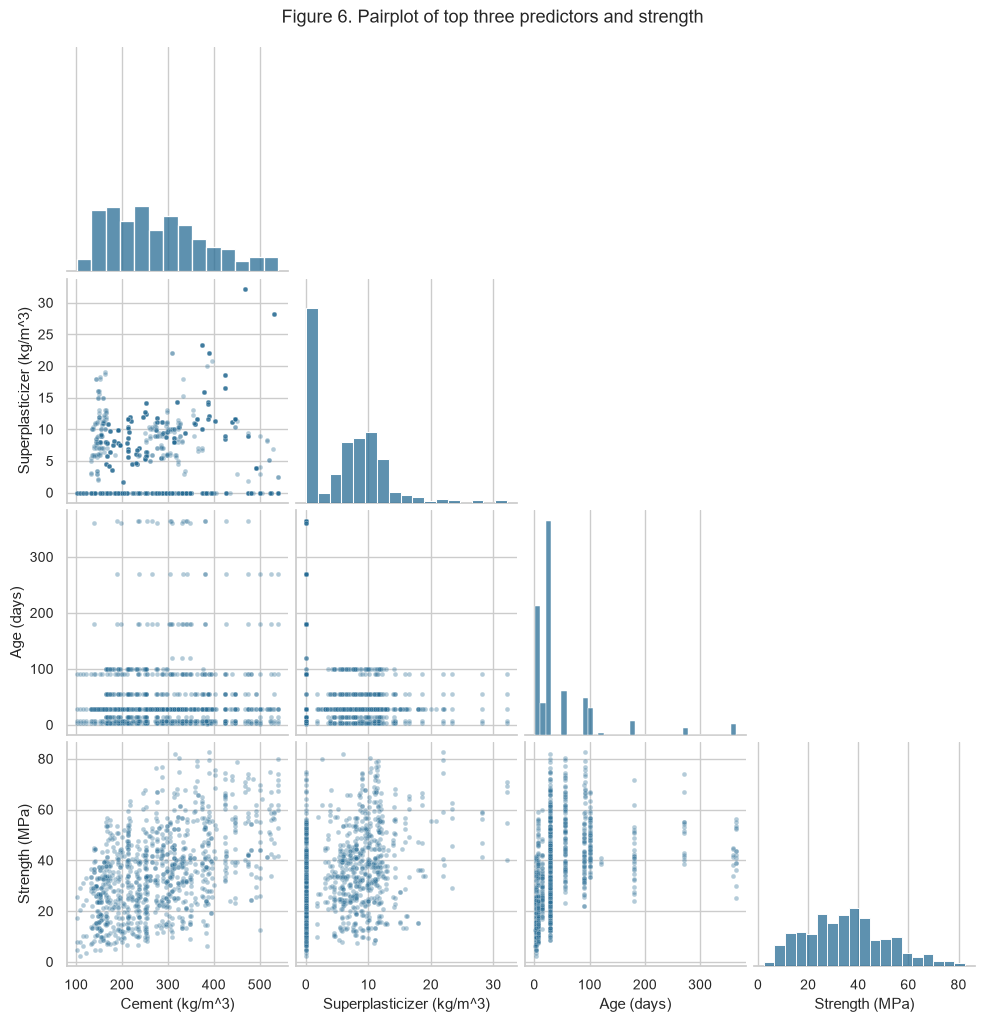

In [9]:
key = list(top3.index) + ['strength']
g = sns.pairplot(clean[key], diag_kind='hist', corner=True,
                 plot_kws={'alpha': 0.35, 's': 12, 'color': '#286c94'},
                 diag_kws={'color': '#286c94'})
for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is not None:
            if i == len(key) - 1: ax.set_xlabel(labels[key[j]])
            if j == 0 and i > 0: ax.set_ylabel(labels[key[i]])
g.fig.suptitle('Figure 6. Pairplot of top three predictors and strength', y=1.02)
show_plot('06_pairplot')

The pairplot complements coefficients by exposing overlapping recipe clusters,
dispersion and curved or age-dependent relationships that a straight-line measure
can miss. The water-superplasticizer association can reflect mixture design choices:
dosage and water are jointly selected, rather than independently assigned.
The 0.70 screen is a chosen diagnostic threshold, not a theorem. Absence of a pair
above it does not rule out multivariable dependence. Future linear modelling should
also check variance inflation and coefficient stability, especially after adding
features derived from existing ingredients.

# Task 6. Engineering interpretation
## What do the correlations mean?
The positive association of cement with strength is compatible with the role of
cementitious binder. A negative water-strength association is compatible with the
importance of water relative to binder, rather than interpreting water in isolation.
Age is associated with the development of strength, but its effect need not be linear.
These interpretations are hypotheses consistent with the data, not causal estimates.
Superplasticizer's positive association is compatible with its role in mixture
workability and water reduction, but dosage may also track high-strength recipe
choices. Age has a stronger Spearman association than Pearson association in this
sample, supporting investigation of a monotonic, nonlinear age-strength relation.

## Unexpected or easily misread patterns
Slag and fly ash may have weak marginal associations despite their engineering
relevance. Their amounts, cement replacement, water and curing age vary together,
so a small marginal coefficient does not show that a material is unimportant.
Different testing ages make unconditional comparisons of mixtures potentially
misleading; comparing 28-day specimens would answer a narrower question.

## Physical and process relationships
Mixtures are constrained combinations of ingredients. Binder composition and
water demand interact, while the age-strength relationship can show diminishing
gains. Candidate features include total binder (cement + slag + fly ash), water
divided by total binder, and log(1 + age). These require testing; the sum of binder
components is a simplification, not an assumption of equal reactivity. Derived
features should not be added indiscriminately alongside all originals in a linear
model because they can increase dependence.

## Important missing features
Curing temperature, curing humidity, specimen geometry, testing protocol, cement
type, aggregate grading, laboratory/batch identity and measurement uncertainty are
not supplied. These can explain residual variation and affect transfer to new
materials or environments. The dataset cannot establish structural suitability.

# Task 7. Challenges encountered and data preparation decisions
The legacy `.xls` format requires `xlrd`; a packaged source workbook avoids a
runtime dependency on UCI availability. Original verbose column names were mapped
to readable names with units recorded explicitly. Exact duplicate records cannot
be distinguished from repeated tests without specimen identifiers. Outlier flags
overlap across columns and are counted both by variable and by distinct row.

Imputing zeros would be unnecessary here and would conflate absent optional
ingredients with unknown measurements in a future dataset. Numerical target binning
also changes the task: it creates ordered classes, not additional predictors or
engineering certification categories. Cleaning decisions are documented and the
untouched source remains available for audit.

In [10]:
# Export raw and cleaned tables without changing the source workbook.
raw.to_csv('data/concrete_raw.csv', index=False)
clean.to_csv('data/concrete_prepared.csv', index=False)
metadata = {
    'source_doi': '10.24432/C5PK67', 'source_rows': len(raw),
    'prepared_rows': len(clean), 'removed_exact_duplicates': extra_duplicates,
    'predictors': predictors, 'units': units,
    'continuous_target': 'strength', 'classification_target': 'strength_class',
    'class_labels': class_labels, 'descriptive_class_edges_MPa': edges.tolist(),
    'class_boundary_convention': 'right-closed; first interval includes minimum',
    'class_edges_scope': 'full cleaned dataset EDA; refit on training for evaluation',
    'outlier_policy': 'retain all IQR flags; no confirmed invalid measurements',
    'source_sha256': hashlib.sha256(DATA.read_bytes()).hexdigest()
}
import json
Path('data/preparation_metadata.json').write_text(json.dumps(metadata, indent=2))
assert clean[predictors].notna().all().all()
assert not clean[columns].duplicated().any()
assert len(predictors) == 8 and 'strength' not in predictors
assert 'strength_class' not in predictors
print('Saved raw CSV, prepared CSV and preparation metadata.')
print('Prepared data:', len(clean), 'rows,', len(clean.columns), 'columns')
print('Eight predictors; two alternative targets; no imputation or outlier deletion.')
print('Integrity checks passed.')

Saved raw CSV, prepared CSV and preparation metadata.
Prepared data: 1005 rows, 10 columns
Eight predictors; two alternative targets; no imputation or outlier deletion.
Integrity checks passed.


# Task 8. Responsible AI reflection
## How could poor quality affect reliability?
Duplicated records may inflate performance if copies cross train/test boundaries.
Unknown or misrecorded units can systematically distort predicted strength.
Deleting legitimate long-age or unusual mixtures can damage reliability at the
edges of the operating range. If recipe families occur at several ages, a random
row split can overstate performance on genuinely new recipes; group evaluation by
recipe, and preferably batch or laboratory, should be considered.

## Ethical and bias issues
The dataset describes selected laboratory mixtures, not a random sample of all
concrete used in construction. Ingredient coverage, curing conditions and material
sources may differ from local practice. Missing provenance makes subgroup auditing
difficult. There are no personal demographic variables, but lack of such variables
does not remove representativeness concerns. Predictions could have safety
consequences if mistaken for certified test results. External validation, uncertainty
reporting and qualified engineering review would be needed before operational use.
Balanced relative classes do not imply balanced coverage of laboratories, recipe
types or rare safety-critical conditions.

# Task 9. Summary report
The following summary follows the supplied Canvas report template. Numerical
findings are printed from the executed analysis below rather than entered by hand.

In [11]:
print('1. DATASET OVERVIEW')
print(f'Raw: {raw.shape[0]} rows x {raw.shape[1]} columns; '
      f'prepared: {clean.shape[0]} rows x {clean.shape[1]} columns.')
print('Target: strength (MPa), continuous regression; four ordered quartile classes.')
print(f'Strength mean={clean.strength.mean():.3f}, '
      f'SD={clean.strength.std():.3f}, '
      f'range={clean.strength.min():.3f}-{clean.strength.max():.3f} MPa.')
print('2. DATA QUALITY')
print(f'Missing values: {int(raw.isna().sum().sum())}; '
      f'exact extra duplicates removed: {extra_duplicates}.')
print(f'IQR flags in {int(flags.any(axis=1).sum())} distinct rows; all retained.')
print('3. UNIVARIATE FINDINGS')
print('Age is strongly right-skewed; optional ingredients have zero-heavy distributions.')
print('4. MULTIVARIATE FINDINGS')
for c, r in top3.Pearson_r.items(): print(f'{c}: Pearson r={r:.4f}')
print(f'Predictor pairs with |r| >= 0.70: {len(high_pairs)}.')
print('Class counts:', counts.to_dict())

1. DATASET OVERVIEW
Raw: 1030 rows x 9 columns; prepared: 1005 rows x 10 columns.
Target: strength (MPa), continuous regression; four ordered quartile classes.
Strength mean=35.250, SD=16.285, range=2.332-82.599 MPa.
2. DATA QUALITY
Missing values: 0; exact extra duplicates removed: 25.
IQR flags in 94 distinct rows; all retained.
3. UNIVARIATE FINDINGS
Age is strongly right-skewed; optional ingredients have zero-heavy distributions.
4. MULTIVARIATE FINDINGS
cement: Pearson r=0.4883
superplasticizer: Pearson r=0.3442
age: Pearson r=0.3374
Predictor pairs with |r| >= 0.70: 0.
Class counts: {'Lower': 252, 'Lower-middle': 252, 'Upper-middle': 250, 'Higher': 251}


## 5. Initial insights for modelling
Start with all eight predictors; the top correlations are useful signals, not a
feature-selection verdict. Compare a regularised linear regression baseline with
tree-based regression for nonlinear relationships. For the derived classification
task, compare an interpretable classifier with a tree ensemble and consider the
ordinal nature of the labels. These are proposed next steps, not implemented models.

Remove or group exact duplicates before splitting. Reserve a test set before any
modelling decisions, and keep related recipes together when evaluating generalisation
to new mixtures. Fit scalers, transformations, any imputer and data-derived class
boundaries only within training folds. Standardisation is useful for linear, distance
and margin-based methods; trees generally do not require it. Optional-ingredient
zeros are valid. Do not include continuous strength or its class label in the
predictor matrix. Report regression MAE/RMSE in MPa; for classification report macro
F1, a confusion matrix and errors across ordered classes, alongside class balance.

## 6. Engineering interpretation
Mixture composition and curing age jointly relate to strength. A nonlinear model
may better represent interactions, but descriptive evidence cannot determine which
model will generalise best. Domain-guided ratios and age transformations should be
compared by validation rather than assumed to improve predictions.

## 7. Challenges encountered
The central challenges are ambiguous duplicate provenance, legitimate statistical
extremes and target discretisation. Decisions preserve an auditable raw dataset and
avoid unsupported imputation or automatic outlier removal.

## 8. Reflection questions
Poor quality can distort estimates and evaluation; laboratory selection and missing
curing/material provenance limit transfer. Model outputs must not replace certified
testing or structural assessment. Detailed reflections appear in Task 8.

## 9. Next steps
Compare results with and without deduplication; analyse 28-day strength separately;
test binder and age features; investigate recipe-group evaluation and external data.
Collect specimen, batch, curing and material-source identifiers where possible.

## 10. GenAI declaration and references
The declaration at the beginning records the actual assistance. Student review is
required before submission, including checking permitted GenAI use.

Yeh, I. (1998). Concrete Compressive Strength [Dataset]. UCI Machine Learning
Repository. https://doi.org/10.24432/C5PK67. Dataset page:
https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength.
License: CC BY 4.0. The original README and workbook are retained with attribution.

Yeh, I.-C. (1998). Modeling of strength of high-performance concrete using artificial
neural networks. Cement and Concrete Research, 28(12), 1797-1808.
https://doi.org/10.1016/S0008-8846(98)00165-3.

Course materials: Portfolio Task 1.pdf and Portfolio Task 1 Submission Document.docx,
provided in the assignment folder.